# Benchmark des algorithmes de repartition de charge

Ce notebook compare 3 approches :
- **Glouton (LPT)**
- **Eager (liste en ligne)**
- **Recherche locale**

Mesures suivies :
- temps d'execution
- precision (`optimum / makespan`)
- taux d'erreur (`(makespan - optimum) / optimum`)

In [3]:
import time
import random
from dataclasses import dataclass
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RNG = random.Random(42)
np.random.seed(42)

## 1) Generation du dataset

In [4]:
@dataclass
class Instance:
    jobs: list
    machines: int
    tier: str


def generate_instance(tier):
    if tier == 'facile':
        n = RNG.randint(8, 12)
        m = RNG.randint(2, 3)
        jobs = [RNG.randint(2, 20) for _ in range(n)]
    elif tier == 'moyen':
        n = RNG.randint(12, 16)
        m = RNG.randint(2, 4)
        jobs = [RNG.randint(1, 35) for _ in range(n)]
    else:  # difficile
        n = RNG.randint(14, 18)
        m = RNG.randint(3, 4)
        jobs = []
        for _ in range(n):
            if RNG.random() < 0.25:
                jobs.append(RNG.randint(40, 90))
            else:
                jobs.append(RNG.randint(1, 25))

    return Instance(jobs=jobs, machines=m, tier=tier)


def generate_test_subset(per_tier=24):
    subset = []
    for tier in ['facile', 'moyen', 'difficile']:
        for _ in range(per_tier):
            subset.append(generate_instance(tier))
    RNG.shuffle(subset)
    return subset


test_subset = generate_test_subset(per_tier=24)
len(test_subset), test_subset[0]

(72,
 Instance(jobs=[4, 15, 20, 20, 18, 12, 10, 8, 12, 9, 10, 14], machines=2, tier='facile'))

In [5]:
dataset_instances_df = pd.DataFrame([
    {
        'instance_id': i,
        'tier': inst.tier,
        'nombre_jobs': len(inst.jobs),
        'machines': inst.machines,
        'charge_totale': sum(inst.jobs),
        'job_moyen': np.mean(inst.jobs),
        'job_max': np.max(inst.jobs),
    }
    for i, inst in enumerate(test_subset)
])

dataset_jobs_df = pd.DataFrame([
    {'instance_id': i, 'tier': inst.tier, 'job': job}
    for i, inst in enumerate(test_subset)
    for job in inst.jobs
])

dataset_instances_df.head()

,instance_id,tier,nombre_jobs,machines,charge_totale,job_moyen,job_max
0,0,facile,12,2,152,12.666667,20
1,1,difficile,18,3,389,21.611111,85
2,2,moyen,15,3,293,19.533333,35
3,3,moyen,15,3,278,18.533333,33
4,4,facile,11,2,113,10.272727,19


### Visualisation du dataset

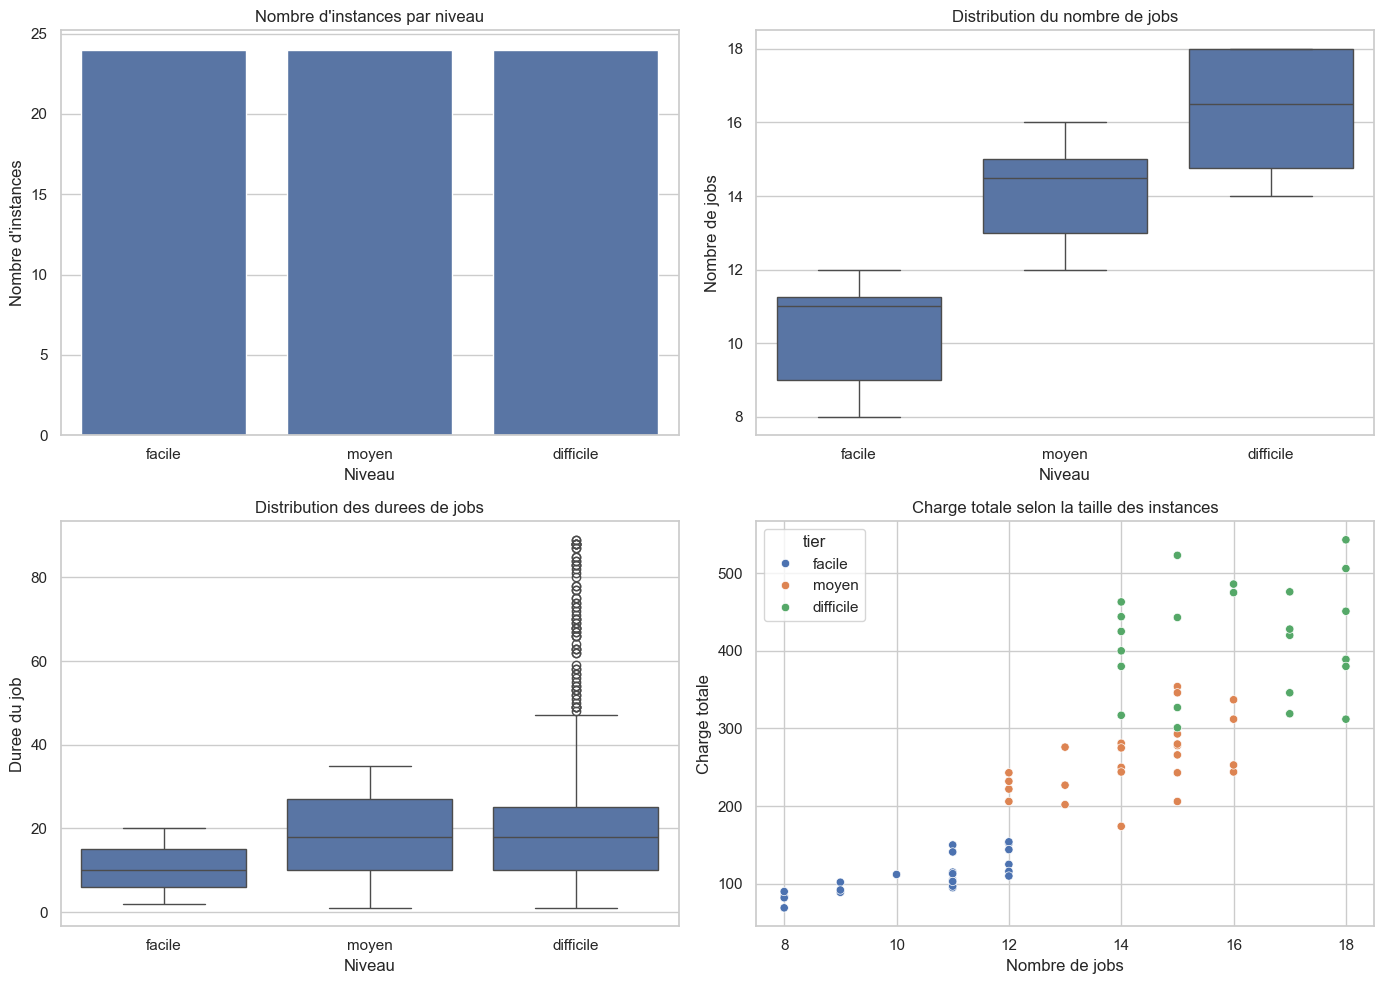

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=dataset_instances_df, x='tier', order=['facile', 'moyen', 'difficile'], ax=axes[0, 0])
axes[0, 0].set_title("Nombre d'instances par niveau")
axes[0, 0].set_xlabel('Niveau')
axes[0, 0].set_ylabel("Nombre d'instances")

sns.boxplot(data=dataset_instances_df, x='tier', y='nombre_jobs', order=['facile', 'moyen', 'difficile'], ax=axes[0, 1])
axes[0, 1].set_title('Distribution du nombre de jobs')
axes[0, 1].set_xlabel('Niveau')
axes[0, 1].set_ylabel('Nombre de jobs')

sns.boxplot(data=dataset_jobs_df, x='tier', y='job', order=['facile', 'moyen', 'difficile'], ax=axes[1, 0])
axes[1, 0].set_title('Distribution des durees de jobs')
axes[1, 0].set_xlabel('Niveau')
axes[1, 0].set_ylabel('Duree du job')

sns.scatterplot(data=dataset_instances_df, x='nombre_jobs', y='charge_totale', hue='tier', hue_order=['facile', 'moyen', 'difficile'], ax=axes[1, 1])
axes[1, 1].set_title('Charge totale selon la taille des instances')
axes[1, 1].set_xlabel('Nombre de jobs')
axes[1, 1].set_ylabel('Charge totale')

plt.tight_layout()
plt.show()

## 2) Algorithmes

In [7]:
def makespan(loads):
    return max(loads) if loads else 0


def assign_job(loads, assignment, machine_idx, job_time):
    loads[machine_idx] += job_time
    assignment[machine_idx].append(job_time)


def pick_least_loaded_machine(loads):
    min_load = min(loads)
    return loads.index(min_load)

In [8]:
def glouton_lpt(jobs, m):
    ordered = sorted(jobs, reverse=True)
    loads = [0] * m
    assignment = [[] for _ in range(m)]
    for job in ordered:
        i = pick_least_loaded_machine(loads)
        assign_job(loads, assignment, i, job)
    return loads, assignment


def eager_online(jobs, m):
    loads = [0] * m
    assignment = [[] for _ in range(m)]
    for job in jobs:
        i = pick_least_loaded_machine(loads)
        assign_job(loads, assignment, i, job)
    return loads, assignment


def recherche_locale(jobs, m, max_iters=2000):
    loads, assignment = glouton_lpt(jobs, m)

    for _ in range(max_iters):
        current_span = makespan(loads)
        best_delta = 0
        best_move = None

        for src in range(m):
            if not assignment[src]:
                continue
            for job in assignment[src]:
                for dst in range(m):
                    if src == dst:
                        continue

                    new_src = loads[src] - job
                    new_dst = loads[dst] + job
                    trial_max = max([new_src if i == src else new_dst if i == dst else loads[i] for i in range(m)])

                    delta = current_span - trial_max
                    if delta > best_delta:
                        best_delta = delta
                        best_move = (src, dst, job)

        if best_move is None:
            break

        src, dst, job = best_move
        assignment[src].remove(job)
        assignment[dst].append(job)
        loads[src] -= job
        loads[dst] += job

    return loads, assignment

In [9]:
def optimum_exact_makespan(jobs, m):
    jobs = tuple(sorted(jobs, reverse=True))
    lower_bound = max(max(jobs), int(np.ceil(sum(jobs) / m)))
    upper_bound = sum(jobs)

    def can_schedule_with_limit(limit):
        @lru_cache(maxsize=None)
        def dfs(idx, loads_state):
            if idx == len(jobs):
                return True

            job = jobs[idx]
            loads = list(loads_state)
            seen = set()

            for i in range(m):
                if loads[i] in seen:
                    continue

                if loads[i] + job <= limit:
                    seen.add(loads[i])
                    loads[i] += job
                    next_state = tuple(sorted(loads))
                    if dfs(idx + 1, next_state):
                        return True
                    loads[i] -= job

                if loads[i] == 0:
                    break

            return False

        return dfs(0, tuple([0] * m))

    lo, hi = lower_bound, upper_bound
    while lo < hi:
        mid = (lo + hi) // 2
        if can_schedule_with_limit(mid):
            hi = mid
        else:
            lo = mid + 1

    return lo

In [10]:
algorithms = {
    'glouton': glouton_lpt,
    'eager': eager_online,
    'recherche_locale': recherche_locale,
}

rows = []

for idx, inst in enumerate(test_subset):
    jobs, m, tier = inst.jobs, inst.machines, inst.tier

    t0 = time.perf_counter()
    optimum = optimum_exact_makespan(jobs, m)
    t_opt = (time.perf_counter() - t0) * 1000

    for name, fn in algorithms.items():
        start = time.perf_counter()
        loads, _ = fn(jobs, m)
        elapsed_ms = (time.perf_counter() - start) * 1000

        span = makespan(loads)
        precision = optimum / span if span > 0 else 0
        error_rate = (span - optimum) / optimum if optimum > 0 else 0

        rows.append({
            'instance_id': idx,
            'tier': tier,
            'jobs_count': len(jobs),
            'machines': m,
            'algorithm': name,
            'optimum': optimum,
            'makespan': span,
            'exec_time_ms': elapsed_ms,
            'precision': precision,
            'error_rate': error_rate,
            'opt_solver_time_ms': t_opt,
        })

df = pd.DataFrame(rows)
df.head()

,instance_id,tier,jobs_count,machines,algorithm,optimum,makespan,exec_time_ms,precision,error_rate,opt_solver_time_ms
0,0,facile,12,2,glouton,76,78,0.013500,0.974359,0.026316,0.171041
1,0,facile,12,2,eager,76,78,0.007209,0.974359,0.026316,0.171041
2,0,facile,12,2,recherche_locale,76,78,0.021166,0.974359,0.026316,0.171041
3,1,difficile,18,3,glouton,130,131,0.011708,0.992366,0.007692,0.260750
4,1,difficile,18,3,eager,130,165,0.008958,0.787879,0.269231,0.260750


## 3) Charts et comparaisons

In [11]:
resume = (
    df.groupby('algorithm', as_index=False)
      .agg(
          temps_moyen_ms=('exec_time_ms', 'mean'),
          temps_p95_ms=('exec_time_ms', lambda x: np.percentile(x, 95)),
          precision_moyenne=('precision', 'mean'),
          erreur_moyenne=('error_rate', 'mean'),
          taux_optimal=('error_rate', lambda x: float(np.mean(np.isclose(x, 0.0)))),
      )
      .sort_values('erreur_moyenne')
)
resume

,algorithm,temps_moyen_ms,temps_p95_ms,precision_moyenne,erreur_moyenne,taux_optimal
1,glouton,0.006826,0.011102,0.986304,0.014144,0.375000
2,recherche_locale,0.023587,0.042227,0.986304,0.014144,0.375000
0,eager,0.005266,0.007416,0.897809,0.122246,0.041667


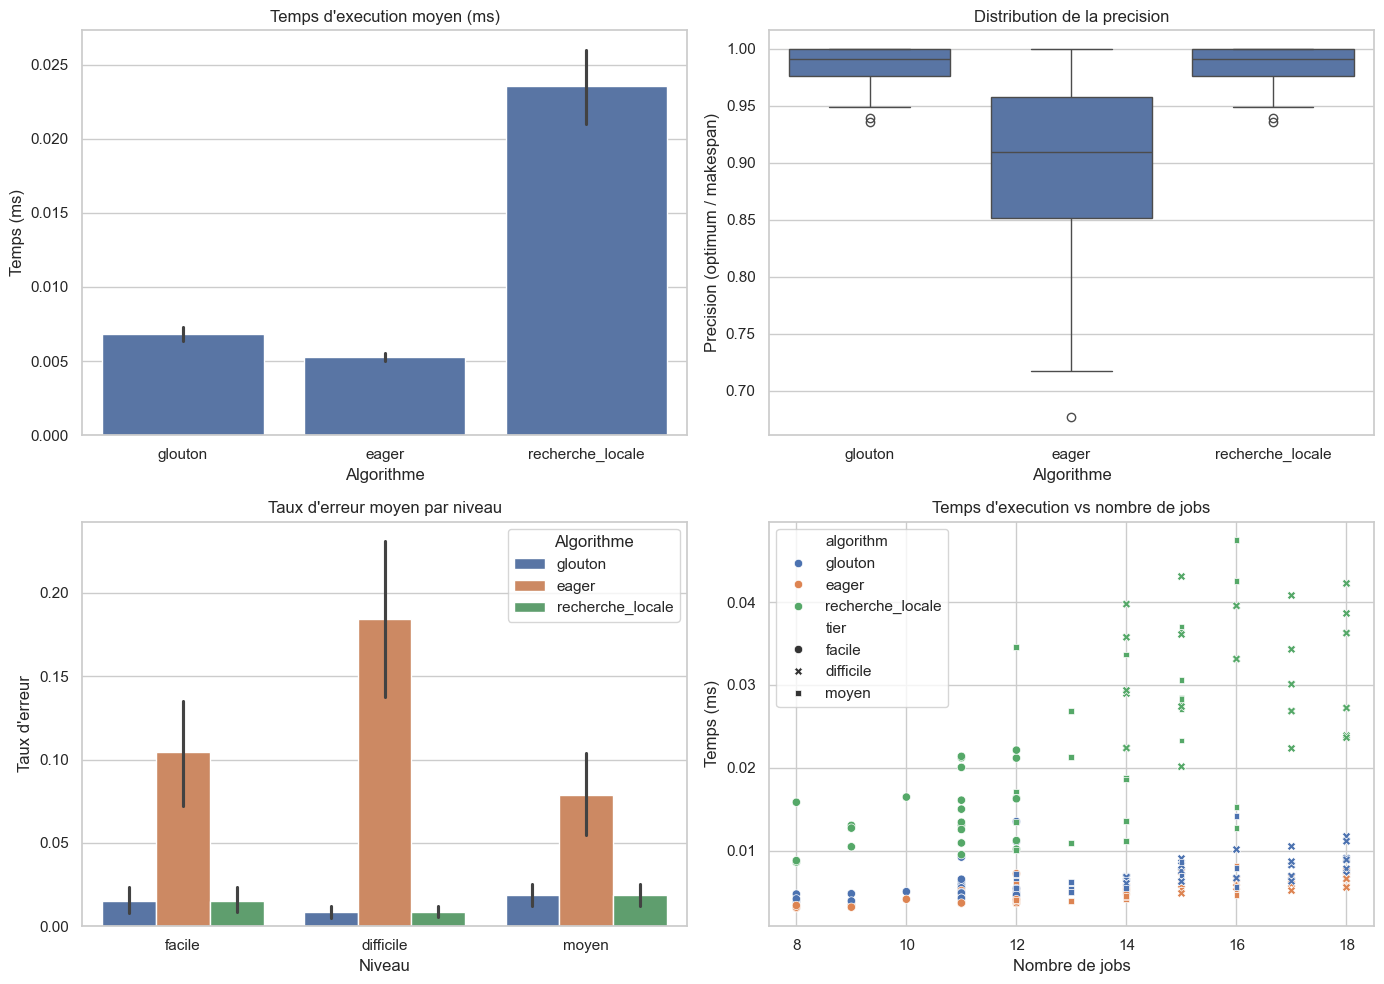

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=df, x='algorithm', y='exec_time_ms', estimator=np.mean, errorbar=('ci', 95), ax=axes[0, 0])
axes[0, 0].set_title("Temps d'execution moyen (ms)")
axes[0, 0].set_xlabel('Algorithme')
axes[0, 0].set_ylabel('Temps (ms)')

sns.boxplot(data=df, x='algorithm', y='precision', ax=axes[0, 1])
axes[0, 1].set_title('Distribution de la precision')
axes[0, 1].set_xlabel('Algorithme')
axes[0, 1].set_ylabel('Precision (optimum / makespan)')

sns.barplot(data=df, x='tier', y='error_rate', hue='algorithm', estimator=np.mean, errorbar=('ci', 95), ax=axes[1, 0])
axes[1, 0].set_title("Taux d'erreur moyen par niveau")
axes[1, 0].set_xlabel('Niveau')
axes[1, 0].set_ylabel("Taux d'erreur")
axes[1, 0].legend(title='Algorithme')

sns.scatterplot(data=df, x='jobs_count', y='exec_time_ms', hue='algorithm', style='tier', ax=axes[1, 1])
axes[1, 1].set_title("Temps d'execution vs nombre de jobs")
axes[1, 1].set_xlabel('Nombre de jobs')
axes[1, 1].set_ylabel('Temps (ms)')

plt.tight_layout()
plt.show()

In [13]:
def scorecard(df):
    out = []
    for alg, part in df.groupby('algorithm'):
        out.append({
            'algorithme': alg,
            'temps_moyen_ms': part['exec_time_ms'].mean(),
            'temps_median_ms': part['exec_time_ms'].median(),
            'precision_moyenne': part['precision'].mean(),
            'precision_mediane': part['precision'].median(),
            'erreur_moyenne': part['error_rate'].mean(),
            'erreur_max': part['error_rate'].max(),
            'hits_optimaux': int(np.sum(np.isclose(part['error_rate'], 0.0))),
            'instances': len(part),
        })
    return pd.DataFrame(out).sort_values(['erreur_moyenne', 'temps_moyen_ms'])

scorecard(df)

,algorithme,temps_moyen_ms,temps_median_ms,precision_moyenne,precision_mediane,erreur_moyenne,erreur_max,hits_optimaux,instances
1,glouton,0.006826,0.006479,0.986304,0.991302,0.014144,0.068182,27,72
2,recherche_locale,0.023587,0.022229,0.986304,0.991302,0.014144,0.068182,27,72
0,eager,0.005266,0.005271,0.897809,0.909044,0.122246,0.476636,3,72


## Remarques

- Augmenter `per_tier` pour avoir une comparaison statistique plus stable.
- Si le calcul exact devient lent, reduire la taille du niveau `difficile`.
- Ajouter des mouvements de swap en recherche locale pour gagner en precision (au prix du temps).